In [45]:
import numpy as np
import globals as gl
import nibabel as nb
import os
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('default')

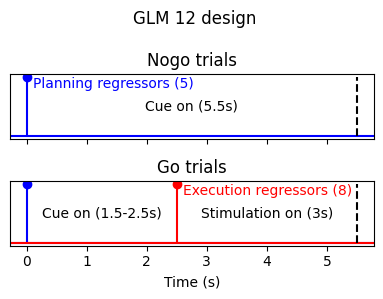

In [46]:
fig, axs = plt.subplots(2, sharex=True, sharey=True, figsize=(4, 3))

axs[0].axhline(0, color='blue')
axs[0].stem(0, 1, linefmt='b-', )
axs[0].set_title('Nogo trials')
axs[0].vlines(5.5, 0, 1,  color='k', ls='--')
axs[0].text(2.75, .5, 'Cue on (5.5s)', ha='center', va='center')
axs[0].text(.1, 1, 'Planning regressors (5)', ha='left', va='top', color='blue')
axs[0].set_yticks([])

axs[1].axhline(0, color='blue')
axs[1].stem(0, 1, linefmt='b-')
axs[1].set_title('Go trials')
axs[1].axhline(0, color='red')
axs[1].stem(2.5, 1, linefmt='r-')
axs[1].vlines(5.5, 0, 1,  color='k', ls='--')
axs[1].set_yticks([])
axs[1].text(1.25, .5, 'Cue on (1.5-2.5s)', ha='center', va='center')
axs[1].text(4, .5, 'Stimulation on (3s)', ha='center', va='center')
axs[1].text(2.6, 1, 'Execution regressors (8)', ha='left', va='top', color='red')
axs[1].set_xlabel('Time (s)')

fig.suptitle(f'GLM 12 design')
fig.tight_layout()

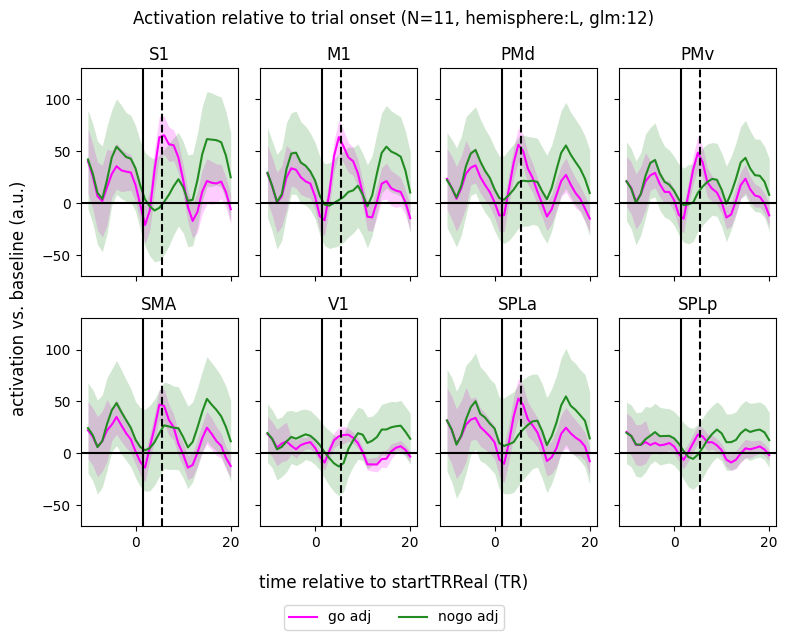

In [47]:
experiment = 'smp2'
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
r = 1
glm = 12

g_atlas = nb.load(os.path.join(gl.atlas_dir, f'ROI.32k.{Hem}.label.gii'))

labels = {
    ele.key: getattr(ele, 'label', '')
    for ele in g_atlas.labeltable.labels
}

y_adj_go = nb.load(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}', f'ROI.y_adj.go.cut.ptseries.nii'))
y_adj_nogo = nb.load(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}', f'ROI.y_adj.nogo.cut.ptseries.nii'))

parcel_axis = y_adj_go.header.get_axis(1)

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(8, 6))
for i in range(2):
    for j in range(4):

        y_adj_go_tmp = np.array(y_adj_go.dataobj)[:, parcel_axis.name==f'CortexLeft_{r:02d}']
        y_adj_nogo_tmp = np.array(y_adj_nogo.dataobj)[:, parcel_axis.name==f'CortexLeft_{r:02d}']

        y_adj_go_avg = y_adj_go_tmp.mean(axis=1)
        y_adj_nogo_avg = y_adj_nogo_tmp.mean(axis=1)

        y_adj_go_err = y_adj_go_tmp.std(axis=1) / np.sqrt(y_adj_go_tmp.shape[1])
        y_adj_nogo_err = y_adj_nogo_tmp.std(axis=1) / np.sqrt(y_adj_nogo_tmp.shape[1])

        if r == 1:
            axs[i, j].plot(y_adj_go.header.get_axis(0), y_adj_go_avg, color='magenta', label='go adj', ls='-')
            axs[i, j].plot(y_adj_nogo.header.get_axis(0), y_adj_nogo_avg, color='forestgreen', label='nogo adj', ls='-')
        else:
            axs[i, j].plot(y_adj_go.header.get_axis(0), y_adj_go_avg, color='magenta',  ls='-')
            axs[i, j].plot(y_adj_nogo.header.get_axis(0), y_adj_nogo_avg, color='forestgreen',  ls='-')
        axs[i, j].fill_between(y_adj_go.header.get_axis(0), y_adj_go_avg-y_adj_go_err, y_adj_go_avg+y_adj_go_err, color='magenta', lw=0, alpha=0.2)
        axs[i, j].fill_between(y_adj_go.header.get_axis(0), y_adj_nogo_avg-y_adj_nogo_err, y_adj_nogo_avg+y_adj_nogo_err, color='forestgreen', lw=0, alpha=0.2)

        axs[i, j].axvline(1.5, color='k', ls='-')
        axs[i, j].axvline(5.5, color='k', ls='--')
        axs[i, j].axhline(0, color='k', ls='-')

        axs[i, j].set_ylim((-70, 130))

        axs[i, j].set_title(labels[r])

        r = r + 1

fig.supylabel('activation vs. baseline (a.u.)')
fig.supxlabel('time relative to startTRReal (TR)')
fig.suptitle(f'Activation relative to trial onset (N={y_adj_go_tmp.shape[1]}, hemisphere:{Hem}, glm:{glm})')

fig.legend(ncol=2, loc='upper center', bbox_to_anchor=(.5, 0))

fig.tight_layout()

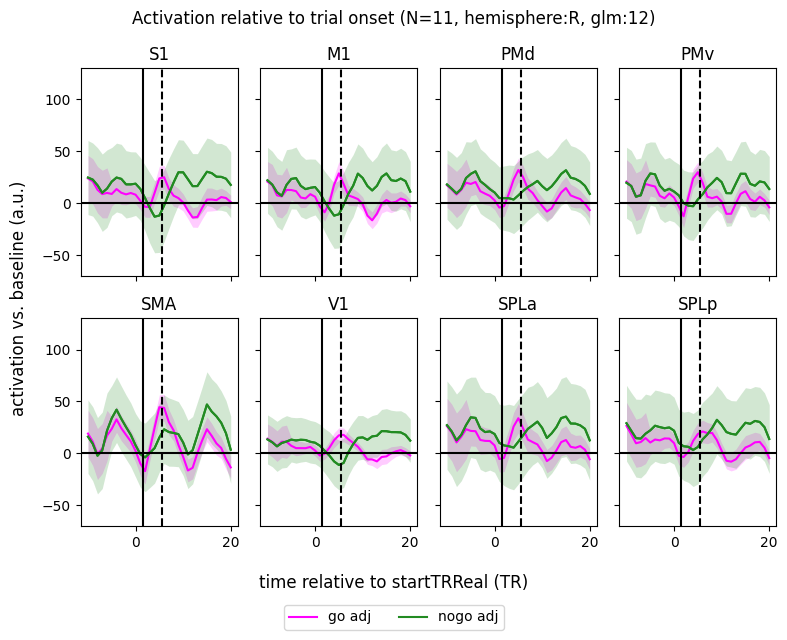

In [48]:
experiment = 'smp2'
Hem = 'R'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
r = 1
glm = 12

g_atlas = nb.load(os.path.join(gl.atlas_dir, f'ROI.32k.{Hem}.label.gii'))

labels = {
    ele.key: getattr(ele, 'label', '')
    for ele in g_atlas.labeltable.labels
}

y_adj_go = nb.load(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}', f'ROI.y_adj.go.cut.ptseries.nii'))
y_adj_nogo = nb.load(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}', f'ROI.y_adj.nogo.cut.ptseries.nii'))

parcel_axis = y_adj_go.header.get_axis(1)

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(8, 6))
for i in range(2):
    for j in range(4):

        y_adj_go_tmp = np.array(y_adj_go.dataobj)[:, parcel_axis.name==f'CortexRight_{r:02d}']
        y_adj_nogo_tmp = np.array(y_adj_nogo.dataobj)[:, parcel_axis.name==f'CortexRight_{r:02d}']

        y_adj_go_avg = y_adj_go_tmp.mean(axis=1)
        y_adj_nogo_avg = y_adj_nogo_tmp.mean(axis=1)

        y_adj_go_err = y_adj_go_tmp.std(axis=1) / np.sqrt(y_adj_go_tmp.shape[1])
        y_adj_nogo_err = y_adj_nogo_tmp.std(axis=1) / np.sqrt(y_adj_nogo_tmp.shape[1])

        if r == 1:
            axs[i, j].plot(y_adj_go.header.get_axis(0), y_adj_go_avg, color='magenta', label='go adj', ls='-')
            axs[i, j].plot(y_adj_nogo.header.get_axis(0), y_adj_nogo_avg, color='forestgreen', label='nogo adj', ls='-')
        else:
            axs[i, j].plot(y_adj_go.header.get_axis(0), y_adj_go_avg, color='magenta',  ls='-')
            axs[i, j].plot(y_adj_nogo.header.get_axis(0), y_adj_nogo_avg, color='forestgreen',  ls='-')
        axs[i, j].plot(y_adj_nogo.header.get_axis(0), y_adj_nogo_avg, color='forestgreen', ls='-')
        axs[i, j].fill_between(y_adj_go.header.get_axis(0), y_adj_go_avg-y_adj_go_err, y_adj_go_avg+y_adj_go_err, color='magenta', lw=0, alpha=0.2)
        axs[i, j].fill_between(y_adj_go.header.get_axis(0), y_adj_nogo_avg-y_adj_nogo_err, y_adj_nogo_avg+y_adj_nogo_err, color='forestgreen', lw=0, alpha=0.2)

        axs[i, j].axvline(1.5, color='k', ls='-')
        axs[i, j].axvline(5.5, color='k', ls='--')
        axs[i, j].axhline(0, color='k', ls='-')

        axs[i, j].set_ylim((-70, 130))

        axs[i, j].set_title(labels[r])

        r = r + 1

fig.supylabel('activation vs. baseline (a.u.)')
fig.supxlabel('time relative to startTRReal (TR)')
fig.suptitle(f'Activation relative to trial onset (N={y_adj_go_tmp.shape[1]}, hemisphere:{Hem}, glm:{glm})')

fig.legend(ncol=2, loc='upper center', bbox_to_anchor=(.5, 0))

fig.tight_layout()